## Tarea 4 - Ejercicio de preprocesamiento y normalización de texto
**Nombre: Sergio Trejo**

**Matricula: 261539**

**Materia: Procesamiento de lenguaje natural_A_Presencial_260206**

## Ejercicio de preprocesamiento y normalización de texto

**Actividad:** Preparar los datos textuales para que puedan ser analizados o utilizados de manera más eficiente por algoritmos de procesamiento de lenguaje natural (PLN) o modelos de aprendizaje automático


**Realizar lo siguiente en un script de Python:**
Genere un script en Python donde aplique las técnicas de preprocesamiento y normalización de texto al dataset indicado (archivo tuits_cambio_climatico.csv) para mostrar en una gráﬁca de barras las primeras 20 palabras con mayor frecuencia y mostrar una nube de palabras. No muestre palabras que no aporten algún sentido a los tuits, muestre solo palabras relevantes. Para implementar el script Utilice funciones. El texto de los tuits está almacenado en la columna llamada ‘tuit’ del dataset. Para leer los tuits utiliza/investiga la librería Pandas.
Para realizar esta actividad, termina de revisar la presentación: Tema 2: Preprocesamiento de texto - Parte 1.


**Entregables:**
•	Código Python ya sea .py o ipynb. Incluso, puedes copiar el código a un documento de Word y subir el documento.



In [35]:
import pandas as pd
import re
import emoji
import matplotlib.pyplot as plt
from collections import Counter
import unicodedata
from spellchecker import SpellChecker
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from wordcloud import WordCloud
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [36]:
df = pd.read_csv('/content/drive/MyDrive/ClassFiles/tuits_cambio_climatico.csv')
df.head(20)

,tuit
0,Excelente iniciativa de el uso de energías ren...
1,Inspirador que la contaminación plástica afect...
2,Datos muestran que los niveles de CO2 disminuy...
3,Indignante que las temperaturas globales sigan...
4,Inspirador que la deforestación continúe 🌊 #So...
5,Investigación revela que la deforestación cont...
6,Me alegra que las temperaturas globales sigan ...
7,Inaceptable que las temperaturas globales siga...
8,Datos muestran que los niveles de CO2 disminuy...
9,Estadísticas indican que la deforestación cont...


In [37]:
#Limpieza de tokens para remover URLs, menciones, hashtags, numeros, puntuaciones, emojis
def limpiar_texto(texto):
  texto = texto.lower() #minusculas
  texto = emoji.replace_emoji(texto, replace='') #eliminar emojis
  texto = re.sub(r'https?://\S+|www\.\S+', '', texto) #eliminar URLs
  texto = re.sub(r'@\w+', '', texto) #eliminar menciones
  texto = re.sub(r'#', '', texto) #eliminar hashtags
  texto = re.sub(r'\d+', '', texto) #eliminar numeros
  texto = re.sub(r'[^\w\s]', '', texto) #eliminar puntuaciones
  return texto

### Limpieza general del texto

**Conclusion:** En este bloque se busca limpiar el texto para quitar informacion que no es util para el analisis de palabras. Se convierten todas las letras a minusculas para evitar que una misma palabra se cuente como diferente. Tambien se tomo la decision de eliminar emojis, enlaces, menciones, numeros, hashtags y signos de puntuacion porque no aportan informacion importante sobre el tema. Por ejemplo los emojis se removieron porque el analisis se enfoca en palabras. Los emojis no son palabras y pueden afectar los resultados o el contexto. Tambien se quita el simbolo "#" para conservar la palabra del hashtag. El objetivo es dejar solo palabras limpias que puedan analizarse correctamente.

## Generar un dataframe nuevo con la ayuda de pandas con el texto limpio.

In [38]:
df["tuits_limpios"] = df["tuit"].apply(limpiar_texto)
df.head(20)

,tuit,tuits_limpios
0,Excelente iniciativa de el uso de energías ren...,excelente iniciativa de el uso de energías ren...
1,Inspirador que la contaminación plástica afect...,inspirador que la contaminación plástica afect...
2,Datos muestran que los niveles de CO2 disminuy...,datos muestran que los niveles de co disminuya...
3,Indignante que las temperaturas globales sigan...,indignante que las temperaturas globales sigan...
4,Inspirador que la deforestación continúe 🌊 #So...,inspirador que la deforestación continúe sost...
5,Investigación revela que la deforestación cont...,investigación revela que la deforestación cont...
6,Me alegra que las temperaturas globales sigan ...,me alegra que las temperaturas globales sigan ...
7,Inaceptable que las temperaturas globales siga...,inaceptable que las temperaturas globales siga...
8,Datos muestran que los niveles de CO2 disminuy...,datos muestran que los niveles de co disminuya...
9,Estadísticas indican que la deforestación cont...,estadísticas indican que la deforestación cont...


**Conclusion:**
En este bloque se aplica la funcion de limpieza a cada tuit del dataset.
Se crea una nueva columna llamada "tuits_limpios" para guardar el texto ya procesado, sin modificar el texto original.
Esto permite comparar el antes y despues del preprocesamiento y trabajar unicamente con texto limpio para el analisis.

## Obtener las 20 palabras mas frecuentes

In [39]:
#Tokenizar y eliminar stopwords usando NLTK
stopwords_nltk = set(stopwords.words('spanish'))
todas_las_palabras = []

for texto in df["tuits_limpios"]:
  tokens = word_tokenize(texto, language='spanish')
  tokens_filtrados = [palabra for palabra in tokens if palabra not in stopwords_nltk and palabra.isalpha()]

  todas_las_palabras.extend(tokens_filtrados)

#Contador de frecuencias
contador = Counter(todas_las_palabras)
palabras_frecuentes = contador.most_common(20)

print('20 palabras mas frecuentes:\n')
for palabra, frecuencia in palabras_frecuentes:
  print(f'{palabra}: {frecuencia}')

palabras = [x[0] for x in palabras_frecuentes]
frecuencias = [x[1] for x in palabras_frecuentes]

20 palabras mas frecuentes:

ecoconciencia: 93
salvemoselplaneta: 91
planeta: 84
cambioclimático: 82
medioambiente: 78
emisiones: 78
gases: 78
efecto: 78
invernadero: 78
reduzcan: 78
uso: 72
energías: 72
renovables: 72
expanda: 72
sostenibilidad: 72
temperaturas: 67
globales: 67
sigan: 67
aumentando: 67
contaminación: 62


**Conclusion:** En este bloque se divide cada tuit limpio en palabras individuales usando tokenizacion.
Despues se eliminan las stopwords del idioma español, ya que son palabras muy comunes como "de", "la" o "y" que no aportan informacion importante al analisis.
Tambien se filtran palabras que no sean letras para evitar incluir simbolos o elementos no deseados.

Finalmente, se cuentan las palabras restantes para identificar las 20 mas frecuentes.
Esto permite detectar los terminos mas relevantes dentro del conjunto de tuits analizados.

## Graficos de barras con las palabras mas frecuentes

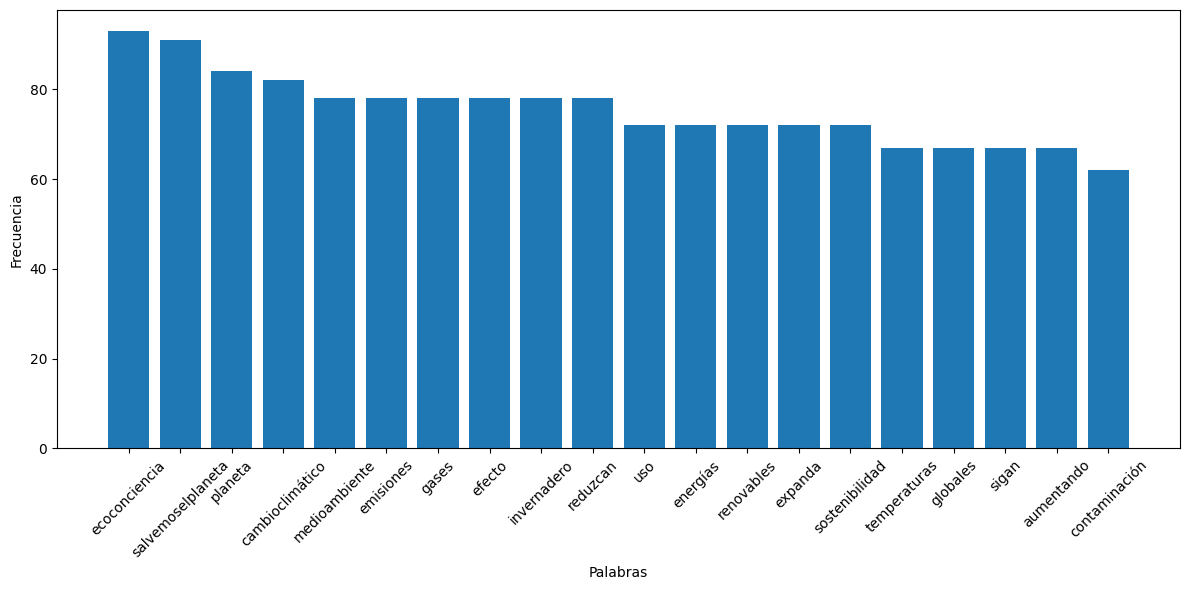

In [40]:
plt.figure(figsize=(12, 6))
plt.bar(palabras, frecuencias)
plt.xticks(rotation=45)
plt.ylabel('Frecuencia')
plt.xlabel('Palabras')
plt.tight_layout()
plt.show()

**Conclusion:**
La grafica muestra las 20 palabras que mas se repiten en los tuits analizados. Se puede observar que palabras relacionadas con el medio ambiente como "planeta", "cambioclimatico", "medioambiente", "emisiones" y "energias" aparecen con mayor frecuencia.

Esto indica que el tema principal del conjunto de datos esta claramente enfocado en el cambio climatico y la sostenibilidad.
La grafica permite identificar rapidamente los conceptos mas importantes dentro del corpus analizado.

## Nube de palabras

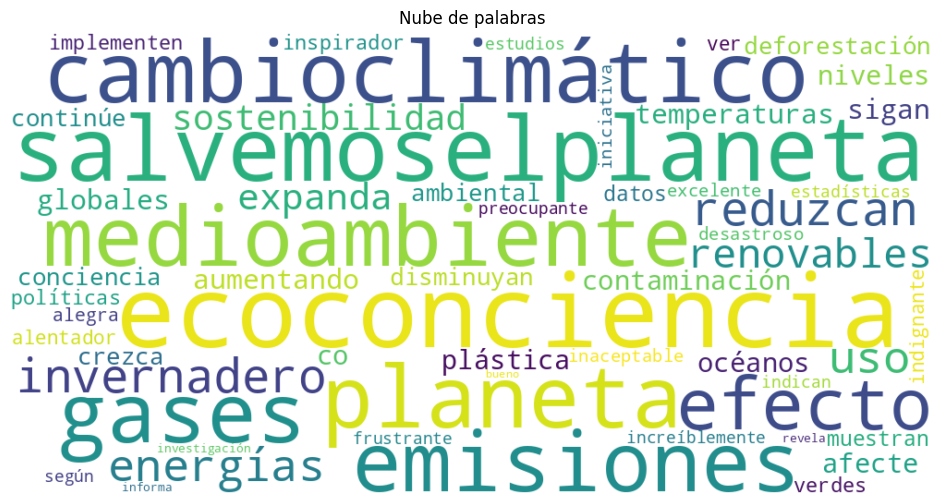

In [41]:
texto_final = " ".join(todas_las_palabras)

plt.figure(figsize=(12,6))
wordcloud = WordCloud(
  width=1000,
  height=500,
  background_color='white',
  collocations=False
).generate(texto_final)

plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title("Nube de palabras")
plt.show()


**Conclusion:** La nube de palabras permite visualizar de forma mas clara cuales son los terminos que mas se repiten en los tuits.
Las palabras mas grandes representan mayor frecuencia dentro del conjunto de datos.

Se observa que terminos como "planeta", "cambioclimatico", "medioambiente", "ecoconciencia", "emisiones" y "gases" destacan en el analisis. Esto confirma que el contenido de los tuits esta enfocado en temas relacionados con el cambio climatico y la sostenibilidad.